# finportfolio — Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mikehv03/finportfolio/blob/main/notebooks/tutorial.ipynb)

**finportfolio** is a Python library for portfolio theory and asset pricing. It implements:

- Markowitz mean-variance optimization
- CAPM, APT, and the Gordon Growth Model
- Single Index Model and Fama-French factor models
- Portfolio performance and risk metrics
- Market data loading via yfinance

---

## 1. Installation

In [1]:
!pip install finportfolio

## 2. Load Market Data

We download adjusted closing prices for a portfolio of 6 assets and the S&P 500, which we will use as a benchmark.

In [3]:
from finportfolio.data import get_prices, get_ff_factors

TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "NVDA"]
BENCHMARK = ["SPY"]
START = "2010-01-01"
END = "2024-12-31"

prices = get_prices(TICKERS, start_date=START, end_date=END)
benchmark_prices = get_prices(BENCHMARK, start_date=START, end_date=END)

print(f"Portfolio prices shape: {prices.shape}")
prices.head()

Portfolio prices shape: (3773, 6)


,AAPL,MSFT,GOOGL,AMZN,JPM,NVDA
Date,,,,,,
2010-01-04,6.412384,23.077387,15.555863,6.6950,28.279186,0.423784
2010-01-05,6.423470,23.084835,15.487361,6.7345,28.826967,0.429972
2010-01-06,6.321296,22.943165,15.096946,6.6125,28.985352,0.432722
2010-01-07,6.309610,22.704565,14.745495,6.5000,29.559517,0.424242
2010-01-08,6.351557,22.861143,14.942070,6.6760,29.486923,0.425159


We download the Fama-French factors directly from Kenneth French's data library.

In [4]:
# Download Fama-French factors
ff_factors = get_ff_factors(start_date=START, end_date=END)
print(f"Fama-French factors shape: {ff_factors.shape}")
ff_factors.head()

Fama-French factors shape: (3774, 4)


,Mkt-RF,SMB,HML,RF
Date,,,,
2010-01-04,0.0169,0.0061,0.0114,0.0
2010-01-05,0.0031,-0.0064,0.0122,0.0
2010-01-06,0.0013,-0.0023,0.0055,0.0
2010-01-07,0.0040,0.0009,0.0096,0.0
2010-01-08,0.0033,0.0036,0.0002,0.0


## 3. Compute Returns

We compute daily simple returns from the adjusted closing prices.

In [5]:
from finportfolio.returns import compute_returns, summary_stats, annualize_returns

returns = compute_returns(prices, method="simple")
benchmark_returns = compute_returns(benchmark_prices, method="simple")

stats = summary_stats(returns, rf=0.0)
print("Summary Statistics (daily):")
stats

Summary Statistics (daily):


,mean,std,skewness,excess_kurtosis,min,max,sharpe_ratio
AAPL,0.001127,0.017554,-0.043243,5.199750,-0.128647,0.119808,0.064181
MSFT,0.000900,0.016111,0.026410,7.654076,-0.147391,0.142169,0.055846
GOOGL,0.000812,0.017218,0.363800,8.201292,-0.116341,0.162584,0.047151
AMZN,0.001140,0.020616,0.260114,6.243431,-0.140494,0.157457,0.055282
JPM,0.000711,0.017494,0.230532,9.926425,-0.149649,0.180125,0.040642
NVDA,0.001940,0.028624,0.620239,8.147203,-0.187559,0.298067,0.067760


We annualize the expected returns by scaling the sample mean by the number of trading days per year (252).

In [6]:
ann_returns = annualize_returns(returns, periods_per_year=252, method="simple")
print("Annualized Expected Returns:")
print(ann_returns.apply(lambda x: f"{x:.2%}"))

Annualized Expected Returns:
AAPL     32.81%
MSFT     25.44%
GOOGL    22.69%
AMZN     33.25%
JPM      19.61%
NVDA     62.95%
dtype: str


## 4. Markowitz Optimization

We find the global minimum variance portfolio using annualized data.

In [7]:
from finportfolio.optimization import Markowitz

# Annualized data
m = Markowitz(returns, annualize=True, periods_per_year=252)

# Global minimum variance portfolio
gmv_weights = m.min_variance()
print("Global Minimum Variance Portfolio Weights:")
print(gmv_weights.apply(lambda x: f"{x:.2%}"))

Global Minimum Variance Portfolio Weights:
AAPL     22.03%
MSFT     28.96%
GOOGL    18.81%
AMZN      7.60%
JPM      32.00%
NVDA     -9.40%
dtype: str


Note: Negative weights indicate short positions, which are allowed in the unconstrained Markowitz framework.

In [8]:
# Performance of GMV portfolio
gmv_perf = m.portfolio_performance(gmv_weights, rf=0.05)
print("GMV Portfolio Performance:")
print(f"  Expected Return: {gmv_perf['expected_return']:.2%}")
print(f"  Risk (std):      {gmv_perf['risk']:.2%}")
print(f"  Sharpe Ratio:    {gmv_perf['sharpe_ratio']:.4f}")

GMV Portfolio Performance:
  Expected Return: 19.99%
  Risk (std):      21.03%
  Sharpe Ratio:    0.7127


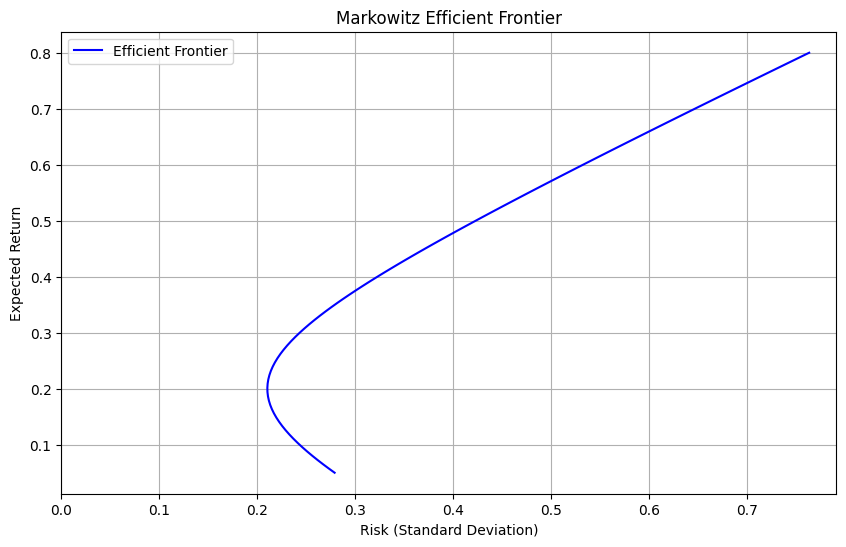

In [9]:
# Plot the efficient frontier
m.plot_frontier(minimum_return=0.05, maximum_return=0.80)

## 5. Tobin

We add a risk-free asset (rf = 5% annual) and find the tangency portfolio.

In [10]:
from finportfolio.optimization import Tobin

risk_free_rate = 0.05

t = Tobin(returns, rf=risk_free_rate, annualize=True, periods_per_year=252)

# Tangency portfolio
tang_weights = t.tangency_portfolio()
print("Tangency Portfolio Weights:")
print(tang_weights.apply(lambda x: f"{x:.2%}"))

Tangency Portfolio Weights:
AAPL      50.51%
MSFT      -4.92%
GOOGL    -24.07%
AMZN      28.42%
JPM        3.89%
NVDA      46.17%
dtype: str


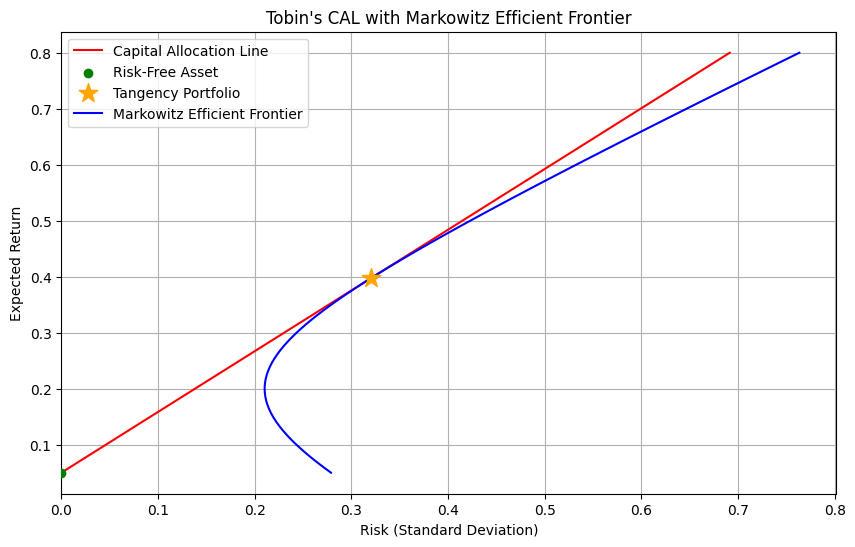

In [11]:
# Plot CAL with Markowitz frontier
t.plot_frontier(minimum_return=0.05, maximum_return=0.80, include_markowitz=True)

## 6. CAPM and Equilibrium Models

We use the CAPM to estimate each asset's systematic risk (beta) and compute equilibrium expected returns based on market exposure.

In [12]:
from finportfolio.equilibrium import estimate_beta, capm_expected_return, security_market_line, plot_security_market_line
import pandas as pd

spy_returns = benchmark_returns["SPY"]
rf_daily = risk_free_rate / 252

# Estimate beta for each asset
betas = {}
for ticker in TICKERS:
    beta = estimate_beta(
        returns[ticker] - rf_daily,
        spy_returns - rf_daily
    )
    betas[ticker] = beta

betas_series = pd.Series(betas)
print("Estimated Betas vs SPY:")
print(betas_series.apply(lambda x: f"{x:.4f}"))

Estimated Betas vs SPY:
AAPL     1.1180
MSFT     1.1318
GOOGL    1.1028
AMZN     1.1493
JPM      1.1991
NVDA     1.6571
dtype: str


Using the estimated betas and the annualized SPY return as the market return, we compute the CAPM equilibrium expected return for each asset.

In [13]:
# CAPM expected returns
market_return = annualize_returns(benchmark_returns, periods_per_year=252)["SPY"]

capm_returns = {}
for ticker in TICKERS:
    capm_returns[ticker] = capm_expected_return(risk_free_rate, betas[ticker], market_return)

print("CAPM Expected Returns (annual):")
for ticker, r in capm_returns.items():
    print(f"  {ticker}: {r:.2%}")

CAPM Expected Returns (annual):
  AAPL: 16.60%
  MSFT: 16.74%
  GOOGL: 16.44%
  AMZN: 16.92%
  JPM: 17.44%
  NVDA: 22.19%


We compute the Security Market Line, based on all the data we have.

In [14]:
# Security Market Line
import numpy as np
sml = security_market_line(
    betas=np.linspace(0, 2, 50),
    rf=risk_free_rate,
    market_return=market_return
)
print("SML (first 5 rows):")
sml.head()

SML (first 5 rows):


,beta,expected_return
0,0.000000,0.050000
1,0.040816,0.054235
2,0.081633,0.058470
3,0.122449,0.062704
4,0.163265,0.066939


NFLX Beta:            1.1142
NFLX Observed Return: 55.87%
NFLX CAPM Return:     16.56%
NFLX Jensen's Alpha:  39.31%


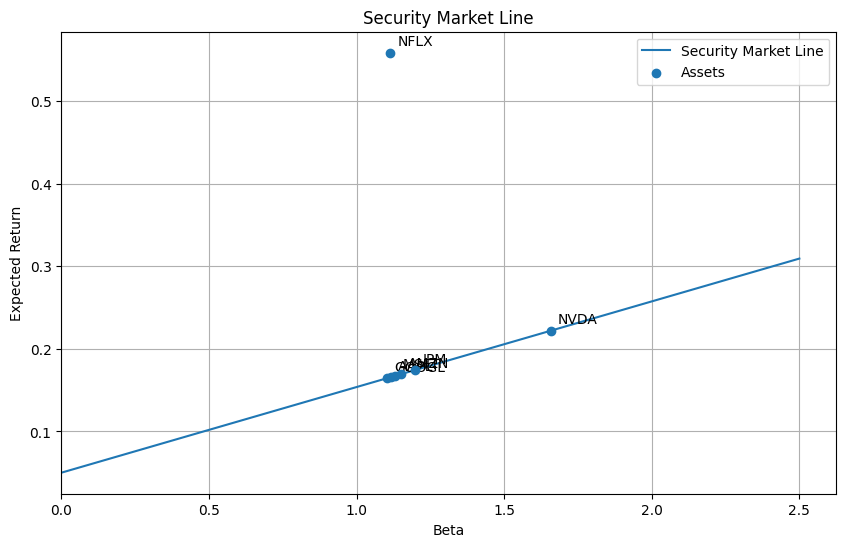

In [15]:
# Download and compute NFLX returns
nflx_prices = get_prices(["NFLX"], start_date=START, end_date=END)
nflx_returns = compute_returns(nflx_prices, method="simple")["NFLX"]

# Align NFLX and SPY returns by index
nflx_aligned, spy_aligned = nflx_returns.align(spy_returns, join="inner")

# Estimate NFLX beta
nflx_beta = estimate_beta(
    nflx_aligned - rf_daily,
    spy_aligned - rf_daily
)

# Annualized observed return
nflx_ann_return = annualize_returns(nflx_returns.to_frame(), periods_per_year=252)["NFLX"]

# CAPM equilibrium return
nflx_capm_return = capm_expected_return(risk_free_rate, nflx_beta, market_return)

print(f"NFLX Beta:            {nflx_beta:.4f}")
print(f"NFLX Observed Return: {nflx_ann_return:.2%}")
print(f"NFLX CAPM Return:     {nflx_capm_return:.2%}")
print(f"NFLX Jensen's Alpha:  {nflx_ann_return - nflx_capm_return:.2%}")

# Add NFLX to the plot
# Activos originales sobre la SML (rendimientos CAPM)
all_betas = pd.concat([betas_series, pd.Series({"NFLX": nflx_beta})])
all_returns = pd.concat([pd.Series(capm_returns), pd.Series({"NFLX": nflx_ann_return})])

plot_security_market_line(
    betas=np.linspace(0, 2.5, 100),
    rf=risk_free_rate,
    market_return=market_return,
    asset_betas=all_betas,
    asset_returns=all_returns
)

**Note:** The portfolio assets lie on the SML by construction, as their expected returns were 
derived from the same betas and market return used to build the line. NFLX is an external asset 
whose observed return was not constrained to the SML, revealing its mispricing.

## 7. Gordon Growth Model

We compute the intrinsic value of a stock using the Gordon Growth Model, and the implied 
required return from the market price.

In [16]:
from finportfolio.equilibrium import gordon_model, gordon_model_implied_return

# Intrinsic value of a stock
D1 = 2.50   # expected dividend next period
g  = 0.04   # constant growth rate
r  = 0.09   # required rate of return

price = gordon_model(D1=D1, g=g, r=r)
print(f"Intrinsic value: ${price:.2f}")

# Implied return from market price
market_price = 45
implied_r = gordon_model_implied_return(P=market_price, D1=D1, g=g)
print(f"Implied required return at P=${market_price}: {implied_r:.2%}")

Intrinsic value: $50.00
Implied required return at P=$45: 9.56%


## 8. Single Index Model

We estimate the Single Index Model for Apple ("AAPL"), decomposing its risk into systematic 
and idiosyncratic components.

In [17]:
from finportfolio.factors import single_index_model

# Estimate SIM for AAPL
sim_results = single_index_model(returns["AAPL"], spy_returns)
print("Single Index Model — AAPL vs SPY:")
print(f"  Alpha (intercept):    {sim_results['alpha']:.6f}")
print(f"  Beta:                 {sim_results['beta']:.4f}")
print(f"  R-squared:            {sim_results['r_squared']:.4f}")
print(f"  Residual Variance:    {sim_results['residual_variance']:.8f}")
print(f"  Systematic Variance:  {sim_results['systematic_variance']:.8f}")

Single Index Model — AAPL vs SPY:
  Alpha (intercept):    0.000492
  Beta:                 1.1180
  R-squared:            0.4681
  Residual Variance:    0.00016394
  Systematic Variance:  0.00014424


## 9. Fama-French 3-Factor Model

We estimate the Fama-French 3-Factor Model for Apple ("AAPL"), adding size (SMB) and value (HML) factors to the market exposure.

In [18]:
from finportfolio.factors import fama_french_3factor

ff_results = fama_french_3factor(returns["AAPL"], ff_factors)
print("Fama-French 3-Factor Model — AAPL:")
print(f"  Alpha:        {ff_results['alpha']:.6f}")
print(f"  Beta Market:  {ff_results['beta_market']:.4f}")
print(f"  Beta SMB:     {ff_results['beta_smb']:.4f}")
print(f"  Beta HML:     {ff_results['beta_hml']:.4f}")
print(f"  R-squared:    {ff_results['r_squared']:.4f}")

Fama-French 3-Factor Model — AAPL:
  Alpha:        0.000454
  Beta Market:  1.1123
  Beta SMB:     -0.2595
  Beta HML:     -0.4438
  R-squared:    0.5085


## 10. Portfolio Performance Metrics

We evaluate the equal-weight portfolio against the SPY benchmark using classical risk-adjusted performance metrics.

In [19]:
from finportfolio.performance import RiskReport

# Use equal-weight portfolio vs SPY benchmark
equal_weights = pd.Series([1/6] * 6, index=TICKERS)
portfolio_returns = returns @ equal_weights # Daily portfolio returns

report = RiskReport(
    returns_portfolio=portfolio_returns,
    returns_benchmark=spy_returns,
    rf=rf_daily
)

print("Portfolio Performance Report (daily frequency):")
report.summary()

Portfolio Performance Report (daily frequency):


Sharpe Ratio         0.061046
Treynor Ratio        0.000739
Jensen's Alpha       0.000453
Beta                 1.226357
Max Drawdown        -0.377411
VaR (95%)            0.023494
CVaR (95%)           0.034869
Tracking Error       0.007265
Information Ratio    0.073918
M^2 Measure          0.000854
dtype: float64

In [20]:
# VaR and CVaR
var_95 = report.var(confidence_level=0.95, method="historical")
cvar_95 = report.cvar(confidence_level=0.95)
max_dd = report.max_drawdown()

print(f"VaR  (95%, historical): {var_95:.2%}")
print(f"CVaR (95%, historical): {cvar_95:.2%}")
print(f"Maximum Drawdown:       {max_dd:.2%}")

VaR  (95%, historical): 2.35%
CVaR (95%, historical): 3.49%
Maximum Drawdown:       -37.74%
